# Sampler DDPM adapté avec score exact d'un mélange de deux gaussiennes

Dans ce noteook, on simule une variable cachée propre $X_0$, on observe une variable bruitée $Z_0 = X_0 + \sigma_{\mathrm{base}}\epsilon_0$ with $\epsilon_0 \sim \mathcal{N}(0, \mu_{eps}).$
Dans ce notebook, les données X_0 sont un mélange de deux gaussiennes.

In [3]:

import torch
import matplotlib.pyplot as plt
import numpy as np


seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [32]:

# ============================================================
# Paramètres globaux
# ============================================================

sigma_base = 5
if sigma_base != 0:
    eps_mean = 0 / sigma_base
n_samples = 30000

T = 200
beta_start = 1e-4
beta_end = 0.07

betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Chaque scénario définit : poids pi_k, moyennes mu_k, écarts-types s_k.
mixture_scenarios = {
    "mode_preponderant": {
        "label": "Mode prépondérant : poids 0.85 / 0.15",
        "weights": [0.85, 0.15],
        "means": [-4, 4],
        "stds": [0.75, 0.75],
    },
    "modes_chevauchants": {
        "label": "Modes chevauchants",
        "weights": [0.75, 0.25],
        "means": [-4, 2],
        "stds": [3, 3],
    },
    "mode_3": {
        "label": "Mode 3",
        "weights": [0.75, 0.25],
        "means": [-3, -2],
        "stds": [1, 0.75],
    },
    "mode_4": {
        "label": "Mode 4",
        "weights": [0.5, 0.5],
        "means": [-4, 4],
        "stds": [1, 1],
    },
}

current_scenario_name = None
mixture_weights = None
mixture_means = None
mixture_stds = None


def set_mixture_scenario(name):
    """Charge un scénario de mélange dans les tenseurs globaux."""
    global current_scenario_name, mixture_weights, mixture_means, mixture_stds
    if name not in mixture_scenarios:
        raise ValueError(f"Scénario inconnu : {name}. Choix possibles : {list(mixture_scenarios)}")

    cfg = mixture_scenarios[name]
    current_scenario_name = name
    mixture_weights = torch.tensor(cfg["weights"], dtype=torch.float32, device=device)
    mixture_means = torch.tensor(cfg["means"], dtype=torch.float32, device=device)
    mixture_stds = torch.tensor(cfg["stds"], dtype=torch.float32, device=device)
    mixture_weights = mixture_weights / mixture_weights.sum()
    return cfg


def extract(a, t, x_shape):
    """Extrait a[t] et reformate pour diffusion/broadcasting."""
    out = a.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))


def sigma2_t(t, x_shape):
    """
        sigma_t^2 = sigma_base^2 / 2^t.
    """
    out = sigma_base**2 / (2.0 ** t.float())
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))


def extract_sigma2(t, x_shape):
    """Retourne sigma_t^2 reformatté pour broadcasting."""
    return sigma2_t(t, x_shape).reshape(-1, *([1] * (len(x_shape) - 1)))


set_mixture_scenario("mode_preponderant")
print("Scénario courant :", mixture_scenarios[current_scenario_name]["label"])


Scénario courant : Mode prépondérant : poids 0.85 / 0.15



## Calcul du score exact du mélange

On pose une variable latente de composante $C \in \{1,2\}$ :

$$
\mathbb{P}(C=k)=\pi_k,
\qquad
X_0 \mid C=k \sim \mathcal{N}(\mu_k, s_k^2).
$$

Donc

$$
f_{X_0}(x)=\sum_{k=1}^2 \pi_k\,\varphi(x;\mu_k,s_k^2),
$$

où $\varphi(\cdot;m,v)$ désigne la densité gaussienne de moyenne $m$ et variance $v$.

L'observation initiale est

$$
Z_0 = X_0 + \sigma_{\mathrm{base}}\varepsilon_0,
\qquad
\varepsilon_0 \sim \mathcal{N}(\mu_\varepsilon,1).
$$

Conditionnellement à $C=k$, on a donc

$$
Z_0 \mid C=k
\sim
\mathcal{N}(m_{0,k},v_{0,k}),
$$

avec

$$
m_{0,k}=\mu_k + \sigma_{\mathrm{base}}\mu_\varepsilon,
\qquad
v_{0,k}=s_k^2 + \sigma_{\mathrm{base}}^2.
$$

Le forward DDPM donne

$$
Z_t = \sqrt{\overline{\alpha}_t}\,Z_0 + \sqrt{1-\overline{\alpha}_t}\,\xi_t,
\qquad
\xi_t \sim \mathcal{N}(0,1).
$$

Donc, conditionnellement à $C=k$,

$$
Z_t \mid C=k
\sim
\mathcal{N}(m_{t,k},v_{t,k}),
$$

avec

$$
m_{t,k}=\sqrt{\overline{\alpha}_t}\,m_{0,k},
\qquad
v_{t,k}=\overline{\alpha}_t v_{0,k}+1-\overline{\alpha}_t.
$$

La densité marginale de $Z_t$ reste un mélange :

$$
f_t^Z(z)=\sum_{k=1}^2 \pi_k\,\varphi(z;m_{t,k},v_{t,k}).
$$

On définit les responsabilités posteriori des composantes :

$$
\gamma_k(z,t)
=\mathbb{P}(C=k\mid Z_t=z)
=
\frac{
\pi_k\,\varphi(z;m_{t,k},v_{t,k})
}{
\sum_{j=1}^2 \pi_j\,\varphi(z;m_{t,j},v_{t,j})
}.
$$

Pour chaque composante gaussienne,

$$
\nabla_z\log \varphi(z;m_{t,k},v_{t,k})
=-\frac{z-m_{t,k}}{v_{t,k}},
$$

et

$$

\nabla_z^2\log \varphi(z;m_{t,k},v_{t,k})
=-\frac{1}{v_{t,k}}.
$$

Le score exact du mélange est donc :

$$
\nabla_z\log f_t^Z(z)
= \nabla f_t^Z(z) / f_t^Z(z)
=
-\sum_{k=1}^2 \gamma_k(z,t)\,\frac{z-m_{t,k}}{v_{t,k}}
= - \sum_{k=1}^2 \frac{
\pi_k\,\varphi(z;m_{t,k},v_{t,k})
}{
\sum_{j=1}^2 \pi_j\,\varphi(z;m_{t,j},v_{t,j})
} \frac{z-m_{t,k}}{v_{t,k}}.
$$

et la dérivée seconde utilisée dans la covariance de Tweedie est :

$$
\nabla_z^2\log f_t^Z(z)
=
\sum_{k=1}^2 \gamma_k(z,t)\left[-\frac{1}{v_{t,k}}+(\frac{z-m_{t,k}}{v_{t,k}})^2\right]
-
\left(\sum_{k=1}^2 \gamma_k(z,t)\frac{z-m_{t,k}}{v_{t,k}}\right)^2.
$$



In [33]:

def sample_x0_mixture(batch_size):
    """
    Échantillonne X_0 depuis le mélange courant :
        X_0 ~ sum_k pi_k N(mu_k, s_k^2).
    """
    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True,
    )
    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)
    return means + stds * torch.randn(batch_size, 1, device=device)


def sample_z0_from_x0(x0):
    """
    Modèle d'observation :
        Z_0 = X_0 + sigma_base * epsilon_0,
        epsilon_0 ~ N(eps_mean, 1).
    """
    eps0 = eps_mean + torch.randn_like(x0)
    return x0 + sigma_base * eps0


def sample_joint_data(batch_size):
    """Retourne le couple caché/observé (X_0, Z_0)."""
    x0 = sample_x0_mixture(batch_size)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def log_normal_pdf_1d(z, mean, var):
    """Log-densité gaussienne 1D, avec broadcasting."""
    return -0.5 * (torch.log(2.0 * torch.pi * var) + (z - mean) ** 2 / var)


def mixture_components_at_t(t, z_shape):
    """
    Calcule les moyennes/variances des deux composantes de Z_t.

    Retourne :
        mean_t : shape (batch, K)
        var_t  : shape (batch, K)
    """
    alpha_bar_t = extract(alpha_bars, t, z_shape)  # shape (batch, 1)

    mean_z0_k = mixture_means + sigma_base * eps_mean
    var_z0_k = mixture_stds.pow(2) + sigma_base**2

    mean_t = torch.sqrt(alpha_bar_t) * mean_z0_k.view(1, -1)
    var_t = alpha_bar_t * var_z0_k.view(1, -1) + (1.0 - alpha_bar_t)
    return mean_t, var_t


@torch.no_grad()
def true_score_z_mixture(zt, t, return_details=False):
    """
    Score exact de Z_t lorsque X_0 suit un mélange de deux gaussiennes.

    Formules codées :
        gamma_k(z,t) = pi_k phi(z; m_tk, v_tk) / sum_j pi_j phi(z; m_tj, v_tj)
        score(z,t)   = sum_k gamma_k(z,t) * (-(z - m_tk) / v_tk)
        hessian(z,t) = sum_k gamma_k(z,t) * (h_k + s_k^2) - score(z,t)^2
    """
    mean_t, var_t = mixture_components_at_t(t, zt.shape)

    log_weights = torch.log(mixture_weights.clamp_min(1e-30)).view(1, -1)
    log_comp = log_weights + log_normal_pdf_1d(zt, mean_t, var_t)
    log_den = torch.logsumexp(log_comp, dim=1, keepdim=True)
    gamma = torch.exp(log_comp - log_den)

    score_k = -(zt - mean_t) / var_t
    hessian_k = -1.0 / var_t

    score = torch.sum(gamma * score_k, dim=1, keepdim=True)
    hessian = torch.sum(gamma * (hessian_k + score_k.pow(2)), dim=1, keepdim=True) - score.pow(2)

    if return_details:
        return {
            "score": score,
            "hessian": hessian,
            "responsibilities": gamma,
            "component_scores": score_k,
            "component_hessians": hessian_k,
            "component_means": mean_t,
            "component_vars": var_t,
        }
    return score, hessian



## Backward: adaptation au cas du mélange de Gaussienne

On a, avec $Z_{t-1} = X_{t-1} + \sigma_{t-1}\epsilon_{t-1}$ avec $\epsilon_{t-1} \sim \mathcal{N}(\mu_e, 1)$,

$$
Z_t \mid X_{t-1}=x
\sim
\mathcal{N}\left(
\sqrt{\alpha_t}\left(x+\sigma_{t-1}\mu_e \right),
\delta_t
\right),
$$

avec

$$
\delta_t=\beta_t+\alpha_t\sigma_{t-1}^2.
$$

Le biais dû à la moyenne non nulle du bruit est

$$
b_t=\sqrt{\alpha_t}\sigma_{t-1}\mu_e.
$$

En appliquant Tweedie, on obtient

$$
\mathbb{E}[X_{t-1}\mid Z_t=z]
=
\frac{z-b_t+\delta_t\nabla_z\log f_t^Z(z)}{\sqrt{\alpha_t}}

$$

et

$$

\operatorname{Var}(X_{t-1}\mid Z_t=z)
=
\frac{1}{\alpha_t}
\left[
\delta_t+
\delta_t^2\nabla_z^2\log f_t^Z(z)
\right]
.
$$




In [34]:

@torch.no_grad()
def p_sample_hidden_x_true_score(zt, t):
    """
    Une étape de la chaîne inverse adaptée, avec score exact du mélange.

    Entrée :
        zt : état bruité courant Z_t
        t  : indices temporels

    Sorties :
        z_prev     : échantillon de Z_{t-1}
        x_prev     : échantillon de X_{t-1}
        x_prev_hat : moyenne conditionnelle E[X_{t-1} | Z_t]
    """
    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)

    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    delta_t = beta_t + alpha_t * sigma_prev2

    # Biais induit par E[epsilon_{t-1}] = eps_mean.
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # Score exact et dérivée seconde exacte de la densité marginale f_t^Z.
    score, hessian = true_score_z_mixture(zt, t)

    # Tweedie : moyenne et variance conditionnelles de X_{t-1} | Z_t.
    x_prev_hat = (zt - bias_t + delta_t * score) / torch.sqrt(alpha_t)
    var_x_prev = (delta_t + (delta_t**2) * hessian) / alpha_t


    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * torch.randn_like(zt)

    # Reconstruction de Z_{t-1} à partir de X_{t-1}.
    z_prev = x_prev + sigma_prev * eps_mean + sigma_prev * torch.randn_like(zt)

    return z_prev, x_prev, x_prev_hat


@torch.no_grad()
def sample_hidden_x_from_z_ddpm(n_samples):
    """
    Chaîne inverse complète.

    Retourne :
        x0_hat    : latent généré X_0
        z0_hat    : observé généré Z_0
        trajectory: quelques états intermédiaires
    """
    zt = torch.randn(n_samples, 1, device=device)
    trajectory = []
    x_prev = None

    tracked_steps = {T - 1, 10, 5, 1, 0}

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)
        z_prev, x_prev, x_prev_hat = p_sample_hidden_x_true_score(zt, t)

        if time_step in tracked_steps:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )
        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()
    return x0_hat, z0_hat, trajectory


In [35]:
def run_scenario(name, n_samples=n_samples, bins=140):
    """Lance la simulation complète pour un scénario de mélange."""
    cfg = set_mixture_scenario(name)
    print("\n" + "=" * 80)
    print(cfg["label"])
    print("weights:", cfg["weights"], "means:", cfg["means"], "stds:", cfg["stds"])

    x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm(n_samples=n_samples)
    x0_real, z0_real = sample_joint_data(n_samples)

    x0_real_cpu = x0_real.detach().cpu()
    z0_real_cpu = z0_real.detach().cpu()


    plt.figure(figsize=(10, 4))
    plt.hist(x0_real_cpu.numpy(), bins=bins, density=True, alpha=0.5, label="vrai X_0")
    plt.hist(x0_gen.numpy(), bins=bins, density=True, alpha=0.5, label="X_0 généré")
    plt.hist(z0_real_cpu.numpy(), bins=bins, density=True, alpha=0.5, label="vrai Z_0")
    plt.title(cfg["label"] + " sigma_base = " + str(sigma_base))
    plt.xlabel("valeur")
    plt.ylabel("densité")
    plt.legend()
    plt.show()



    return {
        "name": name,
        "config": cfg,
        "x0_gen": x0_gen,
        "z0_gen": z0_gen,
        "x0_real": x0_real_cpu,
        "z0_real": z0_real_cpu,
        "trajectory": trajectory,
    }



Mode prépondérant : poids 0.85 / 0.15
weights: [0.85, 0.15] means: [-4, 4] stds: [0.75, 0.75]


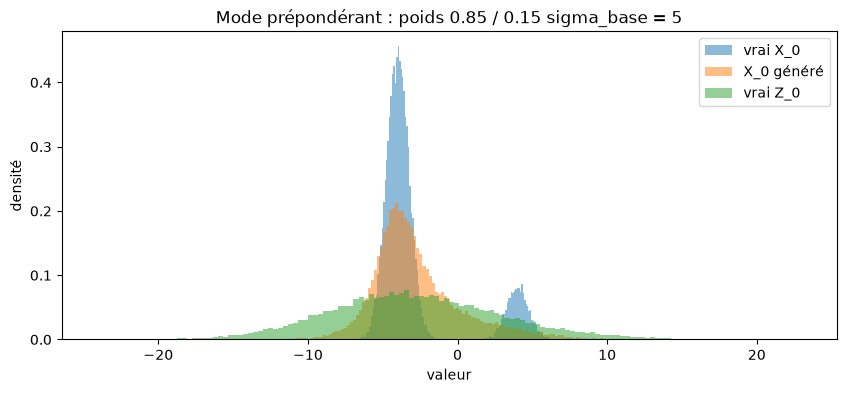

In [36]:

# Expérience 1 : un mode est prépondérant


results_preponderant = run_scenario("mode_preponderant", n_samples=n_samples)


Modes chevauchants
weights: [0.75, 0.25] means: [-4, 2] stds: [3, 3]


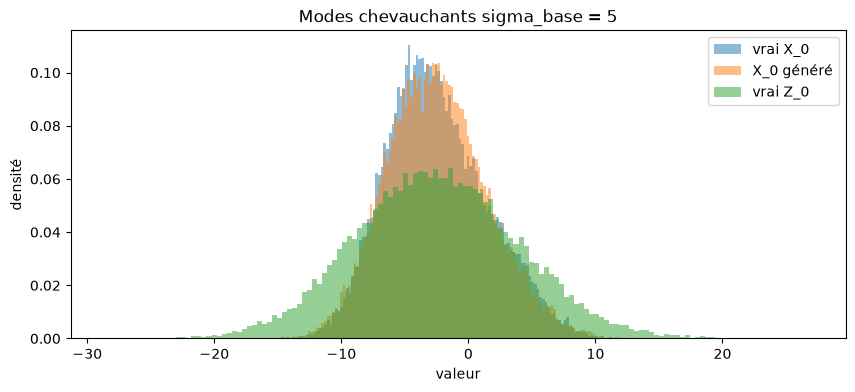

In [37]:

# Expérience 2 : les deux modes se chevauchent


results_overlap = run_scenario("modes_chevauchants", n_samples=n_samples)


Mode 3
weights: [0.75, 0.25] means: [-3, -2] stds: [1, 0.75]


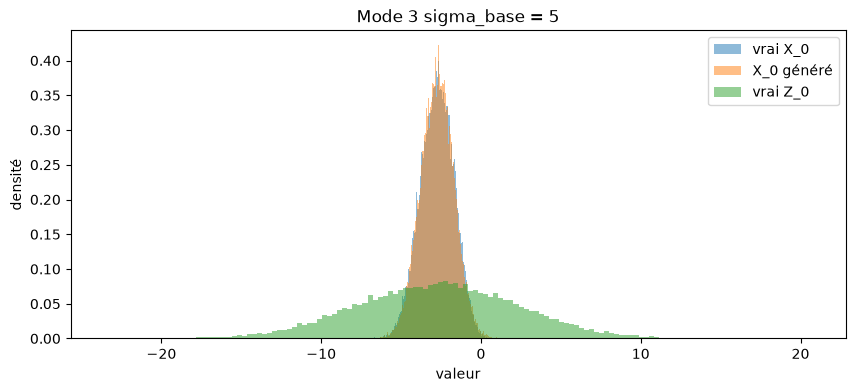

In [38]:

results_overlap = run_scenario("mode_3", n_samples=n_samples)


Mode 4
weights: [0.5, 0.5] means: [-4, 4] stds: [1, 1]


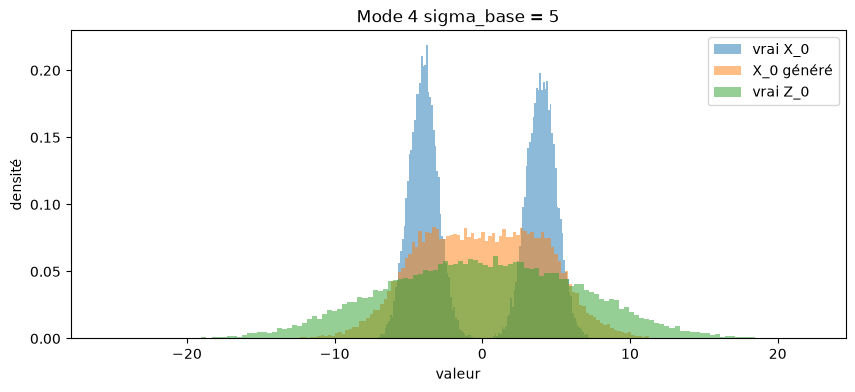

In [39]:
results_overlap = run_scenario("mode_4", n_samples=n_samples)

# Comparison with Tweedie in one step

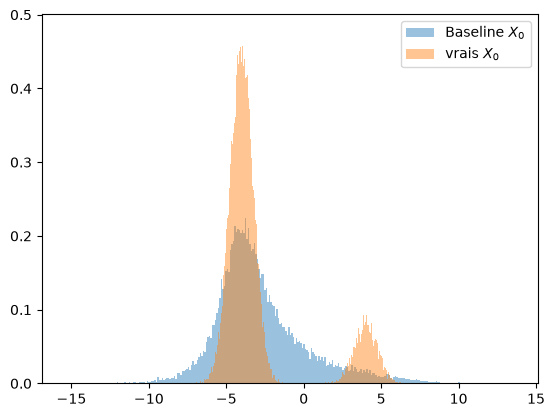

In [40]:
def tweedie_last_step_x0(
    z0,
    correct_variance=False,
):
    """
    Transforme des Z_0 générés en X_0 générés.

    Returns
    -------
    x0_sample : échantillons générés de X_0
    x0_mean   : moyenne de Tweedie E[X_0 | Z_0]
    cond_var  : variance utilisée
    """
    if sigma_base <= 0:
        raise ValueError(
            "sigma_base doit être strictement positif."
        )



    t0 = torch.zeros(
        z0.shape[0],
        device=z0.device,
        dtype=torch.long,
    )

    score_z0, hessian = true_score_z_mixture(z0, t0)

    # Moyenne a posteriori de Tweedie.
    x0_mean = (
        z0
        - sigma_base * eps_mean
        + sigma_base**2 * score_z0
    )

    if correct_variance:
        # Dérivée du score par différence finie comme au dessus



        cond_var = (
            sigma_base**2
            + sigma_base**4 * hessian
        )

    else:

        cond_var = torch.full_like(
            z0,
            sigma_base**2,
        )

    x0_sample = (
        x0_mean
        + torch.sqrt(cond_var) * torch.randn_like(z0)
    )

    return x0_sample, x0_mean, cond_var


# Version avec correction de variance de Tweedie.
cfg = set_mixture_scenario("mode_preponderant")
x0,z0=sample_joint_data(n_samples)
x0_tweedie_variance_corrected, _, var_corrected = (
    tweedie_last_step_x0(
        z0,
        correct_variance=True,
    )
)

plt.hist(
    x0_tweedie_variance_corrected.detach().cpu().numpy(),
    bins=300,
    density=True,
    alpha=0.45,
    label="Baseline $X_0$",
)
plt.hist(
    x0.detach().cpu().numpy(),
    bins=300,
    density=True,
    alpha=0.45,
    label="vrais $X_0$",
)
plt.legend()
plt.show()


Mode prépondérant : poids 0.85 / 0.15
weights: [0.85, 0.15] means: [-4, 4] stds: [0.75, 0.75]


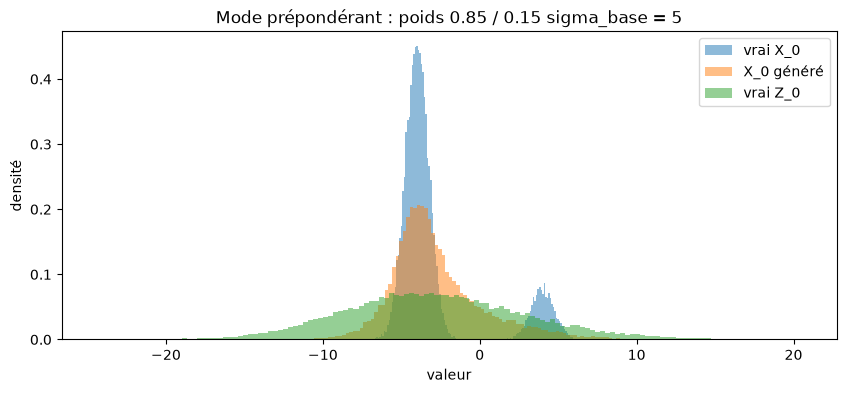

In [41]:
dict=run_scenario("mode_preponderant", n_samples=n_samples)
